# CNG403 Assignment 2 — Personal Face Authentication

**Objective**: Fine-tune a pretrained ResNet18 to classify face images as **YOU** or **NOT YOU**, evaluate it with proper metrics, and deploy it as a Gradio web application.

**You should read, anlayse, debug and undestand the whole codebase NOT just your tasks** 

**Workflow**:
1. [Setup](#1-setup)
2. [Dataset](#2-dataset)
3. [Model](#3-model)
4. [Training](#4-training)
5. [Evaluation](#5-evaluation)
6. [Gradio App](#6-gradio-app)

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, 'src')   # make src/ importable

import json
import numpy as np
import matplotlib.pyplot as plt
import torch

print('PyTorch version :', torch.__version__)
print('Device          :', 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch version : 2.7.1+cu118
Device          : cuda


In [2]:
with open('config.json') as f:
    cfg = json.load(f)

print('Configuration:', json.dumps(cfg, indent=2))

# Seed is fixed — do not change
SEED = cfg['training']['seed']
print(f'\nRandom seed: {SEED}  (do not change)')

Configuration: {
  "training": {
    "batch_size": 16,
    "epochs": 20,
    "learning_rate": 0.001,
    "seed": 42,
    "patience": 7
  },
  "model": {
    "backbone": "resnet18",
    "pretrained": true,
    "num_classes": 2
  },
  "data": {
    "image_size": 224,
    "positive_dir": "data/positive",
    "negative_dir": "data/negative",
    "checkpoint_dir": "checkpoints",
    "log_dir": "logs"
  }
}

Random seed: 42  (do not change)


## 2. Dataset

The negative class is **fixed** for all students: 5 LFW identities, each contributing
4 train / 1 val / 1 test image (20 negatives per split).  
Run the cell below **once** to download and save them automatically.

### 2.1 Download negative class

In [3]:
from dataset import download_negative_class, NEGATIVE_IDENTITIES, NEGATIVE_SPLIT

print(NEGATIVE_IDENTITIES)

download_negative_class(save_dir=cfg['data']['negative_dir'])

print('\nFixed negative identities:')
for name in NEGATIVE_IDENTITIES:
    print(f'  {name}')
print(f'\nSplit indices: {NEGATIVE_SPLIT}')

['Serena Williams', 'Angelina Jolie', 'Alejandro Toledo', 'Recep Tayyip Erdogan', 'George W Bush']
Negative class saved: 30 images --> data\negative/
  train: 20 images
  val  : 5 images
  test : 5 images

Fixed negative identities:
  Serena Williams
  Angelina Jolie
  Alejandro Toledo
  Recep Tayyip Erdogan
  George W Bush

Split indices: {'train': [0, 1, 2, 3], 'val': [4], 'test': [5]}


### 2.2 Add your positive images

Place **30 photos of your own face** into the following folders:

```
data/positive/
    train/   <-- 20 images
    val/     <-- 5  images
    test/    <-- 5  images   ⚠️  DO NOT use these in training or validation
```

Any resolution is fine — images are resized to 224×224 automatically.  
**Do not mix up the splits.** Using test images in training or validation will result in a zero grade.

### 2.3 Sanity checks

In [4]:
from pathlib import Path

pos_dir = Path(cfg['data']['positive_dir'])
neg_dir = Path(cfg['data']['negative_dir'])
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

def count_images(folder):
    folder = Path(folder)
    return sum(1 for p in folder.iterdir() if p.suffix in IMAGE_EXTS)

expected = {'train': (20, 20), 'val': (5, 5), 'test': (5, 5)}
all_ok = True

print(f"{'Split':<8} {'Positive':>10} {'Negative':>10} {'Status':>8}")
print('-' * 42)
for split, (exp_pos, exp_neg) in expected.items():
    n_pos = count_images(pos_dir / split)
    n_neg = count_images(neg_dir / split)
    ok = (n_pos == exp_pos) and (n_neg == exp_neg)
    if not ok:
        all_ok = False
    status = '✓' if ok else '✗'
    print(f'{split:<8} {n_pos:>10} {n_neg:>10} {status:>8}')

if not all_ok:
    print('\n⚠ Some counts are wrong. Check your data/positive/ folders before continuing.')
else:
    print('\nAll image counts correct.')

Split      Positive   Negative   Status
------------------------------------------
train            20         20        ✓
val               5          5        ✓
test              5          5        ✓

All image counts correct.


In [ ]:
# ⚠️  DATA LEAKAGE CHECK — this check will also be run by the grader.
# If any test image appears in train/ or val/, an AssertionError is raised.
from dataset import check_no_test_leakage

check_no_test_leakage(cfg['data']['positive_dir'])

### 2.4 Visualize samples

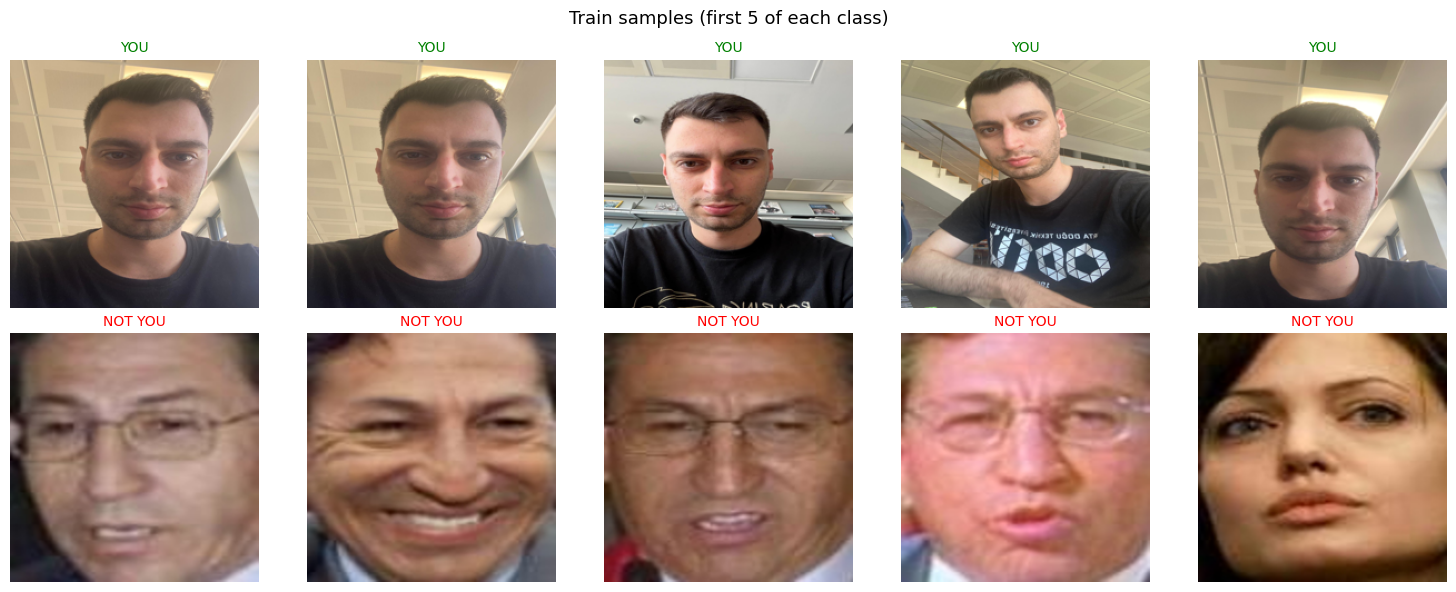

In [5]:
from PIL import Image

def show_samples(pos_folder, neg_folder, n=5, title='Train samples'):
    pos_paths = sorted(p for p in Path(pos_folder).iterdir() if p.suffix.lower() in {'.jpg', '.jpeg', '.png'})[:n]
    neg_paths = sorted(p for p in Path(neg_folder).iterdir() if p.suffix.lower() in {'.jpg', '.jpeg', '.png'})[:n]

    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    fig.suptitle(title, fontsize=13)

    for i, (ax, path) in enumerate(zip(axes[0], pos_paths)):
        ax.imshow(Image.open(path).convert('RGB').resize((224, 224)))
        ax.set_title('YOU', color='green', fontsize=10)
        ax.axis('off')

    for i, (ax, path) in enumerate(zip(axes[1], neg_paths)):
        ax.imshow(Image.open(path).convert('RGB').resize((224, 224)))
        ax.set_title('NOT YOU', color='red', fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_samples(
    pos_folder=pos_dir / 'train',
    neg_folder=neg_dir / 'train',
    title='Train samples (first 5 of each class)',
)

## 3. Model

**YOUR TASK:** Open `src/model.py` and implement `build_model()`.

Run the sanity check below after implementing.

In [6]:
# Sanity check: run src/model.py
%run src/model.py

Running model sanity checks ...

  Total parameters     : 11,177,538
  Frozen parameters    : 11,176,512
  Trainable parameters : 1,026
  Trainable param count ✓
  Output shape torch.Size([4, 2]) ✓
  model.fc is trainable ✓

All model sanity checks passed.


**Q1**: What is transfer learning, and why do we freeze the backbone?

Transfer learning is when we use a model that someone else already trained on a set of data and then we make it work for something new. For this project we are using a pretrained CNN like ResNet18. This is because it already knows what things like edges and shapes and textures look like. It even knows what faces look like.

We do not change the backbone of the model. The reason is that our set of data is really small. We only have 20 pictures to train with. If we tried to train the model it would probably get too good at recognizing those 20 pictures and not good at anything else. This is called overfitting. So we freeze the backbone. Keep all the general things it learned from the big set of data. Then we only train the part of the model the part that figures out what class something belongs to. For us there are two classes: YOU and NOT YOU. We train this part to be good at telling the difference, between these two classes, YOU and NOT YOU.

**Q2**: We have only 20 personal training images. What risks does this create?

I am using 20 pictures of myself for training and that is a big problem. The model might just remember these 20 pictures of learning what my face really looks like. This means it will work fine with these 20 pictures but it will not work well with pictures that have different lighting or angles or if I am making a different face.

It is also a problem because 20 pictures of my face are not enough to show all the ways I can look. To make this better we can use something called transfer learning. We can also freeze the backbone and add some changes to the pictures and keep some pictures separate to test the model and some to check how it is doing.

## 4. Training

**YOUR TASK:** Open `src/train.py` and implement `train_one_epoch()`.

Run training after implementing. You should see val accuracy rise above 0.8 within a few epochs.

In [7]:
import importlib
import train as train_module
importlib.reload(train_module)

history = train_module.run('config.json')

Device: cuda
Train batches: 3  |  Val batches: 1
Epoch   1/20  train_loss=0.6123  train_acc=0.7000  val_loss=0.5647  val_acc=0.7000
  ✓ Best model saved (val_acc=0.7000)
Epoch   2/20  train_loss=0.4054  train_acc=0.9500  val_loss=0.4997  val_acc=0.8000
  ✓ Best model saved (val_acc=0.8000)
Epoch   3/20  train_loss=0.2608  train_acc=1.0000  val_loss=0.4160  val_acc=0.7000
Epoch   4/20  train_loss=0.1862  train_acc=0.9750  val_loss=0.3341  val_acc=1.0000
  ✓ Best model saved (val_acc=1.0000)
Epoch   5/20  train_loss=0.1608  train_acc=1.0000  val_loss=0.2174  val_acc=1.0000
Epoch   6/20  train_loss=0.0846  train_acc=1.0000  val_loss=0.1494  val_acc=1.0000
Epoch   7/20  train_loss=0.1195  train_acc=1.0000  val_loss=0.1132  val_acc=1.0000
Epoch   8/20  train_loss=0.0936  train_acc=1.0000  val_loss=0.0908  val_acc=1.0000
Epoch   9/20  train_loss=0.0679  train_acc=1.0000  val_loss=0.0809  val_acc=1.0000
Epoch  10/20  train_loss=0.0466  train_acc=1.0000  val_loss=0.0681  val_acc=1.0000
Epoch  

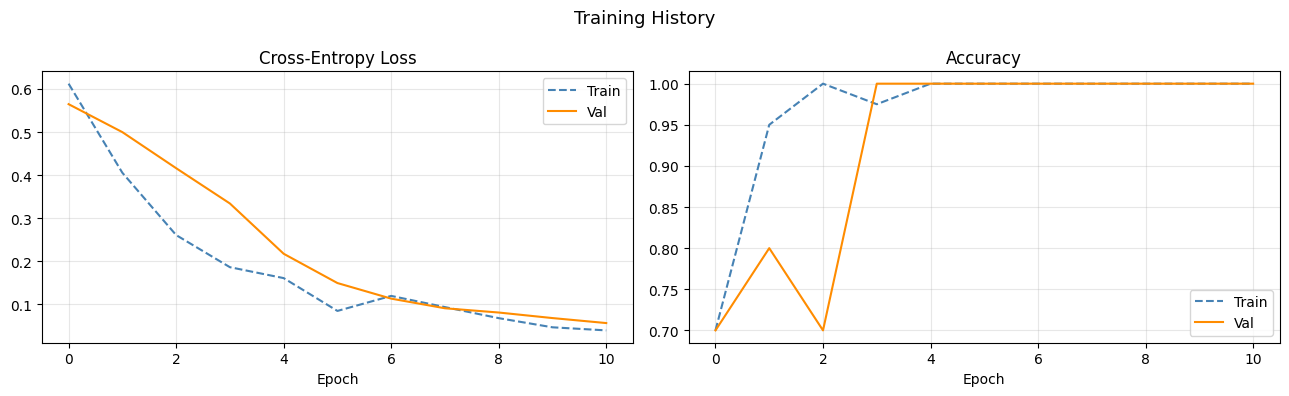

Best val accuracy : 1.0000


In [8]:
history = np.load('logs/history.npy', allow_pickle=True).item()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, title in zip(
    axes,
    ['loss', 'acc'],
    ['Cross-Entropy Loss', 'Accuracy'],
):
    ax.plot(history[f'train_{metric}'], '--', color='steelblue',  label='Train')
    ax.plot(history[f'val_{metric}'],   '-',  color='darkorange', label='Val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=13)
plt.tight_layout()
plt.savefig('logs/training_curves.png', dpi=150)
plt.show()

print(f'Best val accuracy : {max(history["val_acc"]):.4f}')

## 5. Evaluation

**YOUR TASK:** Open `src/evaluate.py` and implement `compute_metrics()`.

Treat label 1 (YOU) as the positive class. Run the sanity check first, then evaluate on the test set.

In [9]:
# Sanity check: run src/evaluate.py
%run src/evaluate.py

Running compute_metrics sanity checks ...

  Perfect-prediction check ✓
  All-negative edge case ✓
  Mixed-prediction check ✓

All compute_metrics sanity checks passed.


In [10]:
import importlib
import evaluate as eval_module
importlib.reload(eval_module)

from model import build_model
from dataset import get_dataloaders

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the best checkpoint
model = build_model(cfg['model']['backbone'], cfg['model']['num_classes'])
model.load_state_dict(torch.load('checkpoints/best_model.pt', map_location=device))
model = model.to(device)

# Get test DataLoader
_, _, test_loader = get_dataloaders(
    positive_dir=cfg['data']['positive_dir'],
    negative_dir=cfg['data']['negative_dir'],
    image_size=cfg['data']['image_size'],
    batch_size=cfg['training']['batch_size'],
)

# Run inference
probs, preds, labels = eval_module.predict_all(model, test_loader, device)
metrics = eval_module.compute_metrics(preds, labels)
eval_module.print_report(metrics, probs, labels)

Evaluation Report  (10 test images)
  Accuracy  : 0.9000
  Precision : 0.8333
  Recall    : 1.0000
  F1 Score  : 0.9091

  #    True       P(YOU)    P(NOT YOU)   Pred
  --------------------------------------------------
  1    YOU        0.9433    0.0567       YOU ✓
  2    YOU        0.8656    0.1344       YOU ✓
  3    YOU        0.8530    0.1470       YOU ✓
  4    YOU        0.8259    0.1741       YOU ✓
  5    YOU        0.8596    0.1404       YOU ✓
  6    NOT YOU    0.4210    0.5790       NOT YOU ✓
  7    NOT YOU    0.5403    0.4597       YOU ✗
  8    NOT YOU    0.4437    0.5563       NOT YOU ✓
  9    NOT YOU    0.4085    0.5915       NOT YOU ✓
  10   NOT YOU    0.1737    0.8263       NOT YOU ✓


**Q3**: What does precision capture that accuracy does not? What does recall capture?

Accuracy tells us how many predictions are correct. It doesn't tell us what kind of mistakes the model makes.

Precision shows how good the model is, at making positive predictions. For example when the model says "this is you" how often is it really you? If the model has precision it won't mistake other peoples faces for yours.

Recall shows how faces that are really yours the model can find. For instance if there are pictures of my face how many of them does the model correctly identify as mine? If the model has recall it will rarely miss my face.

**Q4**: What would happen to the reported test accuracy if you included test images
in the training set? Why does it invalidate the results?

If test photos are placed inside the train, the model will be as if they have seen the exam questions beforehand. Therefore, the test result will not be fair and reliable, which can lead to overfitting

## 6. Gradio App

**YOUR TASK:** Open `src/app.py` and implement `predict()` and `build_app()`

After launching the app below:
1. Upload each of your **5 positive test images** one at a time.
2. Take a screenshot of each prediction showing both class probabilities.
3. Save them as `screenshots/screenshot_1.png` through `screenshots/screenshot_5.png`.

**Submit all 5 screenshots with your assignment.**

In [13]:
!pip install gradio
import importlib
import app as app_module
importlib.reload(app_module)

demo = app_module.build_app(config_path='config.json')
demo.launch()

  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached brotli-1.2.0-cp310-cp310-win_amd64.whl.metadata (6.3 kB)
  Using cached fastapi-0.136.3-py3-none-any.whl.metadata (27 kB)
  Using cached gradio_client-2.5.0-py3-none-any.whl.metadata (7.1 kB)
  Using cached groovy-0.1.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached hf_gradio-0.4.1-py3-none-any.whl.metadata (428 bytes)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached orjson-3.11.9-cp310-cp310-win_amd64.whl.metadata (43 kB)
  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached pydub-0.25.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached pyyaml-6.0.3-cp310-cp310-win_amd64.whl.metadata (2.4 kB)
  Using cached safehttpx-0.1.7-py3-none-any.whl.metadata (4.2 kB)
  Using cached semantic_version-2.10.0-py2.py3-none-any.


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\fatih\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
C:\Users\fatih\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded from checkpoints\best_model.pt (device: cuda)
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## 7 Submission checklist

Before submitting, verify:
- [ ] The notebook has run succesfully and all the outputs are visible.
- [ ] All questions are answered.
- [ ] `screenshots/screenshot_1.png` — test image 1, both probabilities visible
- [ ] `screenshots/screenshot_2.png` — test image 2, both probabilities visible
- [ ] `screenshots/screenshot_3.png` — test image 3, both probabilities visible
- [ ] `screenshots/screenshot_4.png` — test image 4, both probabilities visible
- [ ] `screenshots/screenshot_5.png` — test image 5, both probabilities visible
- [ ] `data/` excluded from submission zip
- [ ] `checkpoints/` excluded from submission zip
- [ ] Random seed is still 42 in `config.json`